In [1]:
import numpy as np 
result = np.load('mcmc_results.npz')

In [2]:
from model import Emulator21cm,run_inference
CHECKPOINT_DEFAULT = "checkpoints/emulator.pt"

import torch

In [3]:
def load_emulator():
    model = Emulator21cm(n_params=6, n_redshifts=3)
    model.load_state_dict(torch.load(CHECKPOINT_DEFAULT, map_location="cpu"))
    return model

In [4]:
model   = load_emulator()
checkpoint_dir = "checkpoints"
scalers = np.load(f"{checkpoint_dir}/scalers.npz")
## Generating obs
split = torch.load("checkpoints/dataset_split.pt")
test_thetas = split["test_thetas"]
test_ps2d = split["test_ps2d"]
test_xhi = split["test_xhi"]
theta_obs = test_thetas[0].numpy()
test_ps2d_obs = test_ps2d[0].numpy().flatten()

In [5]:
ps2d_cur, xhi_cur = run_inference(model, theta_obs,scalers=scalers)

In [6]:
import glob
def log_likelihood(y_obs: np.ndarray, y_pred: np.ndarray, sigma: np.ndarray) -> float:
    return -0.5 * float(np.sum(((y_obs - y_pred) / sigma) ** 2))

sigma = np.concatenate([
    np.loadtxt(f).flatten()
    for f in sorted(glob.glob("PS1_PS2_Data/err_Pk_PS2_*.txt"))
    ])

log_likelihood(test_ps2d_obs, run_inference(model, theta_obs,scalers=scalers)[0].flatten(), sigma)

-0.003971221254204784

In [34]:
theta_median
log_likelihood(test_ps2d_obs, run_inference(model, theta_median,scalers=scalers)[0].flatten(), sigma)

-23.49591630331846

Relative error: 1.0284593


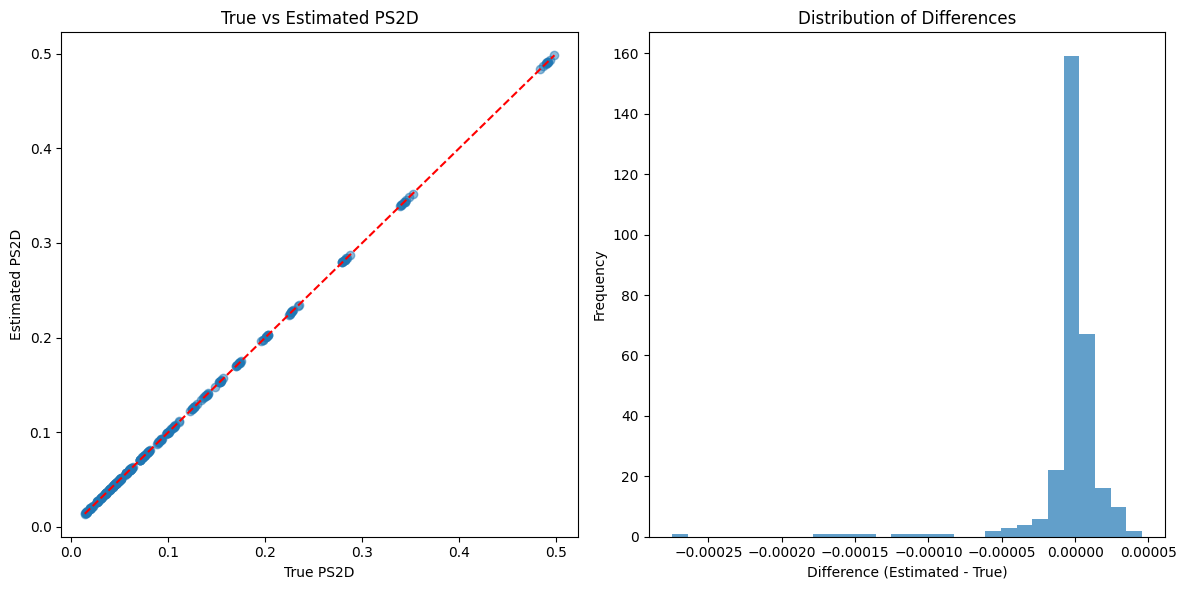

In [28]:
ps2d_estimated = ps2d_cur.flatten()
ps2d_true = test_ps2d_obs 

relative_error = (ps2d_true-ps2d_estimated)/ps2d_true * 100
print("Relative error:", relative_error.max())
#Difference between the two
difference = ps2d_estimated - ps2d_true
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(ps2d_true, ps2d_estimated, alpha=0.5)
plt.plot([ps2d_true.min(), ps2d_true.max()], [ps2d_true.min(), ps2d_true.max()], 'r--')
plt.xlabel('True PS2D')
plt.ylabel('Estimated PS2D')
plt.title('True vs Estimated PS2D')
plt.subplot(1, 2, 2)
plt.hist(difference, bins=30, alpha=0.7)
plt.xlabel('Difference (Estimated - True)')
plt.ylabel('Frequency')
plt.title('Distribution of Differences')
plt.tight_layout()
plt.show()

In [4]:
theta_obs

NameError: name 'theta_obs' is not defined

In [7]:
samples = result["posterior"]

In [8]:
PARAM_NAMES  = ['ALPHA_STAR', 'F_STAR10', 'F_ESC10', 'ALPHA_ESC', 'M_TURN', 't_STAR']


In [25]:
theta_obs = [0.01549499, 0.88349795, 0.7685325, 0.8806733, 0.30912188, 0.46456185]

In [9]:
samples = result['chain']

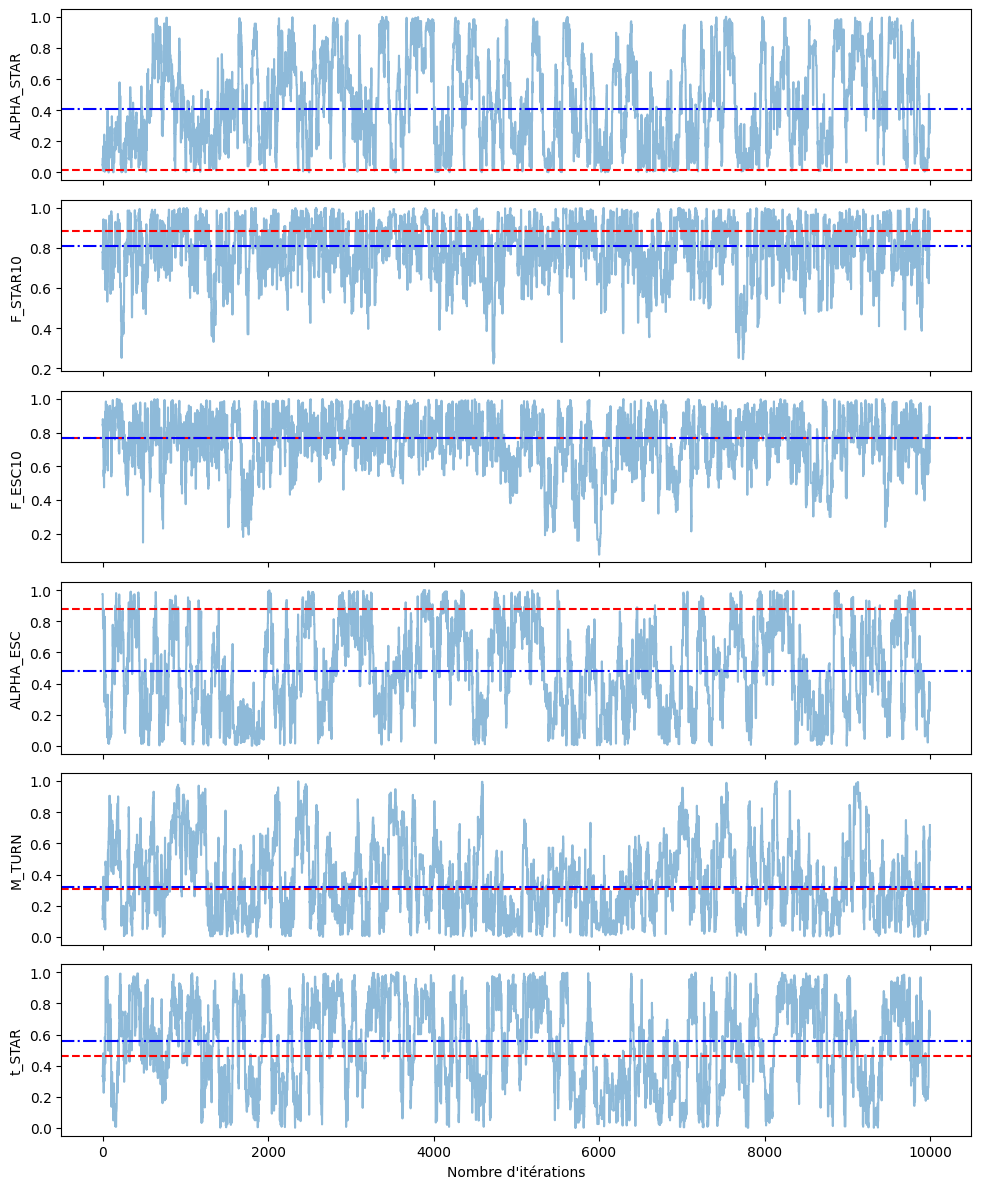

In [39]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(6, 1, figsize=(10, 12), sharex=True)
for i in range(6):
    axes[i].plot(samples[:, i], alpha=0.5)
    axes[i].set_ylabel(PARAM_NAMES[i])
    # Si tu as theta_obs, on l'affiche pour comparer
    theta_median = np.median(samples, axis=0)
    axes[i].axhline(theta_obs[i], color="red", linestyle="--", label="Vrai")
    axes[i].axhline(theta_median[i], color="blue", linestyle="-.", label="Médiane")

plt.xlabel("Nombre d'itérations")
plt.tight_layout()
plt.show()

In [41]:
burn_in = 2500  # 25%
samples_post = samples[burn_in:]

mean   = samples_post.mean(axis=0)
median = np.median(samples_post, axis=0)
std    = samples_post.std(axis=0)
lower  = np.percentile(samples_post, 2.5, axis=0)
upper  = np.percentile(samples_post, 97.5, axis=0)

for i, name in enumerate(PARAM_NAMES):
    in_ci = lower[i] < theta_obs[i] < upper[i]
    print(f"{name}: true={theta_obs[i]:.3f} | mean={mean[i]:.3f} ± {std[i]:.3f} | CI=[{lower[i]:.3f}, {upper[i]:.3f}] | {'✓' if in_ci else '✗'}")

ALPHA_STAR: true=0.015 | mean=0.461 ± 0.304 | CI=[0.014, 0.974] | ✓
F_STAR10: true=0.883 | mean=0.789 ± 0.148 | CI=[0.465, 0.991] | ✓
F_ESC10: true=0.769 | mean=0.739 ± 0.177 | CI=[0.321, 0.989] | ✓
ALPHA_ESC: true=0.881 | mean=0.511 ± 0.283 | CI=[0.033, 0.977] | ✓
M_TURN: true=0.309 | mean=0.333 ± 0.228 | CI=[0.016, 0.860] | ✓
t_STAR: true=0.465 | mean=0.542 ± 0.285 | CI=[0.035, 0.981] | ✓
